# Wisconsin Breast Cancer Clustering (K-Means & DBSCAN)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## 2. Veri Yükleme

In [4]:
import pandas as pd

# Veri yolunu tanımlama
data_path = "./breast+cancer+wisconsin+diagnostic/wdbc.data"

#Özellik isimlerini tanımla
feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Sütun isimlerini oluşturma
column_names = ['id', 'diagnosis'] + feature_names

# Dosyayı okuma
data_df = pd.read_csv(data_path, header=None, names=column_names)

# Özellikleri ve hedef değişkeni ayırma
ozellikler = data_df[feature_names]
y_true = data_df['diagnosis'].map({'M': 0, 'B': 1})  # M=0 (malignant), B=1 (benign)

# Kontrol amaçlı bilgi yazdırma
print(f"Veri seti boyutu: {ozellikler.shape}")
print(f"Malignant (M): {sum(y_true == 0)} örnek")
print(f"Benign (B): {sum(y_true == 1)} örnek")
print("\nİlk 5 satır:")
print(data_df[['id', 'diagnosis'] + feature_names[:5]].head())


Veri seti boyutu: (569, 30)
Malignant (M): 212 örnek
Benign (B): 357 örnek

İlk 5 satır:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  
0          0.11840  
1          0.08474  
2          0.10960  
3          0.14250  
4          0.10030  


## 3. Veri Ön İşleme

In [5]:
ozellikler.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
ozellikler.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [7]:
ozellikler.value_counts()


radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  fractal_dimension_mean  radius_se  texture_se  perimeter_se  area_se  smoothness_se  compactness_se  concavity_se  concave_points_se  symmetry_se  fractal_dimension_se  radius_worst  texture_worst  perimeter_worst  area_worst  smoothness_worst  compactness_worst  concavity_worst  concave_points_worst  symmetry_worst  fractal_dimension_worst
6.981        13.43         43.79           143.5      0.11700          0.07568           0.00000         0.00000              0.1930         0.07818                 0.2241     1.5080      1.553         9.833    0.010190       0.010840        0.00000       0.000000           0.02659      0.004100              7.93          19.54          50.41            185.2       0.1584            0.12020            0.00000          0.00000               0.2932          0.09382                    1
14.860       16.94         

In [8]:
olcekleyici = StandardScaler()
X_scaled = olcekleyici.fit_transform(ozellikler)


## Elbow Yöntemi (K Değeri Belirleme)

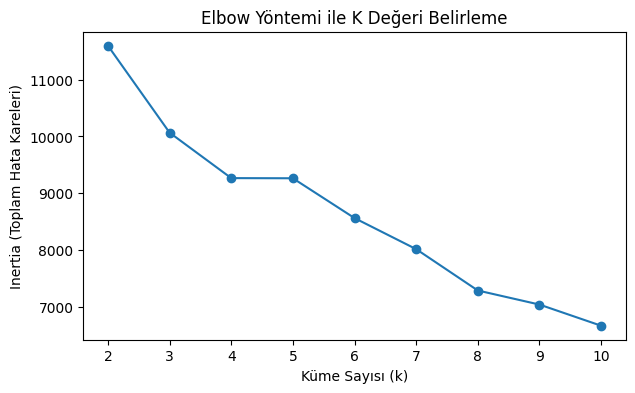

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)  # <--- .fit ile modeli eğitiyoruz
    inertia.append(kmeans.inertia_)  # <--- toplam hata kareleri (inertia)

# Grafik çizimi
plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')  
plt.title('Elbow Yöntemi ile K Değeri Belirleme')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia (Toplam Hata Kareleri)')
plt.show()


## 5. K-Means Kümeleme

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# K-Means modeli oluştur
kmeans = KMeans(n_clusters=2, random_state=42)

# Veriyi modele uygula ve kümeleri tahmin et
labels_kmeans = kmeans.fit_predict(X_scaled)

# Silhouette skorunu hesapla
sil_score_kmeans = silhouette_score(X_scaled, labels_kmeans)
print(f"K-Means Silhouette Skoru: {sil_score_kmeans:.3f}")



K-Means Silhouette Skoru: 0.345


## 6. DBSCAN Kümeleme

In [11]:
dbscan = DBSCAN(eps=2.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

unique_labels = set(labels_dbscan)
print(f"DBSCAN Küme Sayısı (gürültü hariç): {len(unique_labels) - (1 if -1 in labels_dbscan else 0)}")

# Gürültü (noise) oranı:
noise_ratio = np.sum(labels_dbscan == -1) / len(labels_dbscan)
print(f"DBSCAN Gürültü Oranı: {noise_ratio*100:.2f}%")

# Silhouette skoru hesaplama (sadece gürültü olmayan noktalar için)
if len(set(labels_dbscan)) > 1:
    # Gürültü noktalarını çıkararak silhouette skoru hesapla
    non_noise_mask = labels_dbscan != -1
    if np.sum(non_noise_mask) > 1 and len(set(labels_dbscan[non_noise_mask])) > 1:
        sil_score_dbscan = silhouette_score(X_scaled[non_noise_mask], labels_dbscan[non_noise_mask])
        print(f"DBSCAN Silhouette Skoru (gürültü hariç): {sil_score_dbscan:.3f}")
    else:
        print("DBSCAN Silhouette Skoru hesaplanamadı (yetersiz küme)")


DBSCAN Küme Sayısı (gürültü hariç): 4
DBSCAN Gürültü Oranı: 65.20%
DBSCAN Silhouette Skoru (gürültü hariç): 0.098


## 7. Görselleştirme (PCA ile 2D)

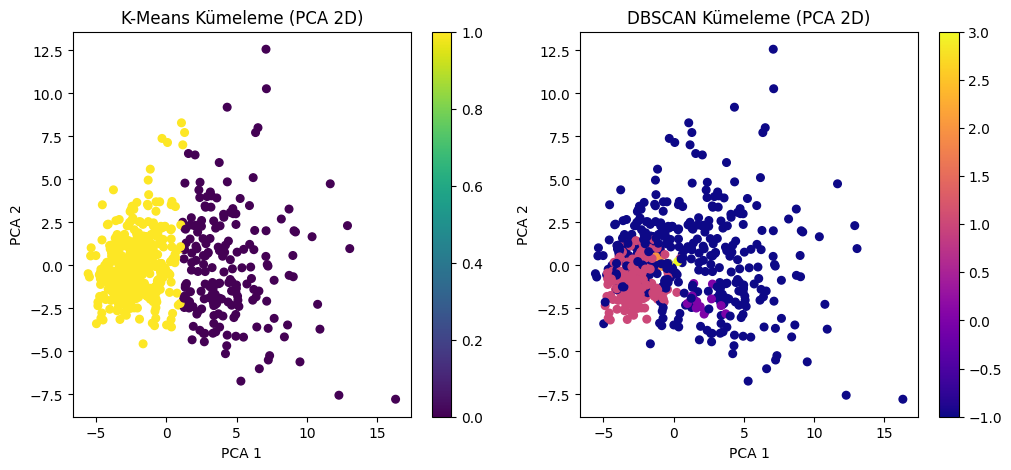

PCA ile açıklanan varyans oranı: 0.632


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='viridis', s=30)
plt.title('K-Means Kümeleme (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar()

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='plasma', s=30)
plt.title('DBSCAN Kümeleme (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar()
plt.show()

print(f"PCA ile açıklanan varyans oranı: {pca.explained_variance_ratio_.sum():.3f}")


## 8. Gerçek Etiketlerle Karşılaştırma

### Crosstab Görselleştirme

In [13]:
print("\nK-Means Küme - Gerçek Etiket Karşılaştırması:")
kmeans_crosstab = pd.crosstab(y_true, labels_kmeans, rownames=['Gerçek'], colnames=['Küme'])
print(kmeans_crosstab)

print("\nDBSCAN Küme - Gerçek Etiket Karşılaştırması:")
dbscan_crosstab = pd.crosstab(y_true, labels_dbscan, rownames=['Gerçek'], colnames=['Küme'])
print(dbscan_crosstab)



K-Means Küme - Gerçek Etiket Karşılaştırması:
Küme      0    1
Gerçek          
0       175   37
1        13  344

DBSCAN Küme - Gerçek Etiket Karşılaştırması:
Küme     -1   0    1   2   3
Gerçek                      
0       191  12    9   0   0
1       180   0  172   3   2


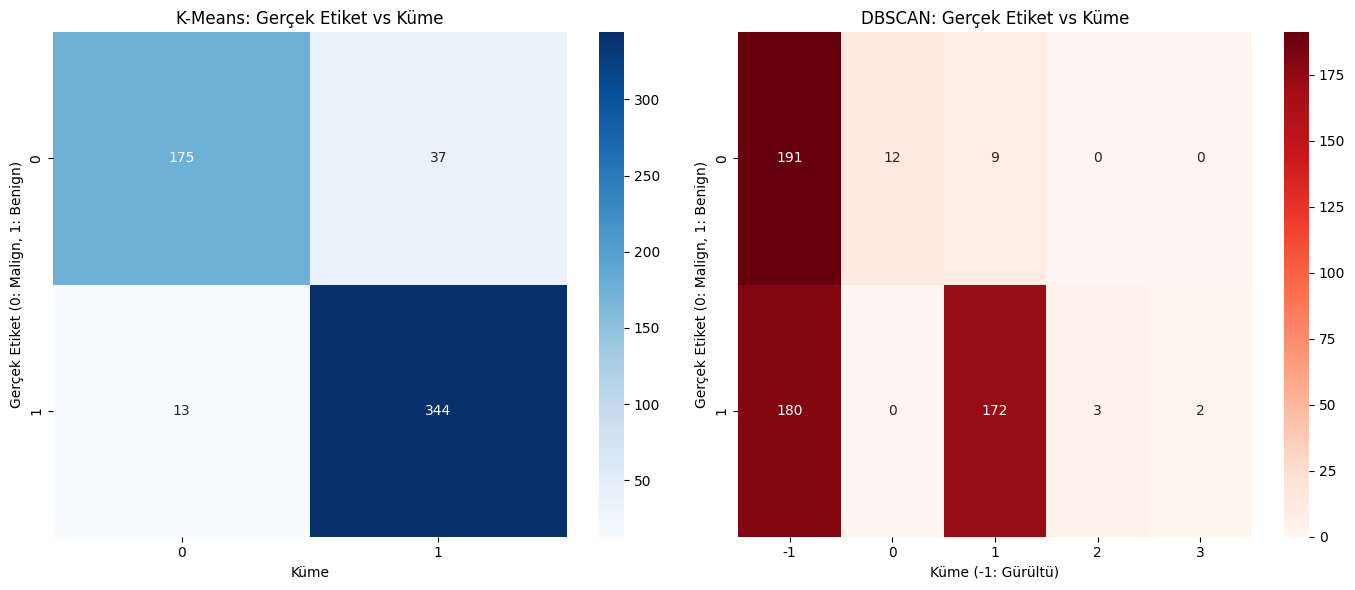


Analiz tamamlandı. K-Means genellikle DBSCAN'den daha iyi ayrım yapar çünkü veri kümesi yoğunluk farkları az.


In [14]:
plt.figure(figsize=(14, 6))

# K-Means Crosstab Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(kmeans_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('K-Means: Gerçek Etiket vs Küme')
plt.xlabel('Küme')
plt.ylabel('Gerçek Etiket (0: Malign, 1: Benign)')

# DBSCAN Crosstab Heatmap
plt.subplot(1, 2, 2)
sns.heatmap(dbscan_crosstab, annot=True, fmt='d', cmap='Reds')
plt.title('DBSCAN: Gerçek Etiket vs Küme')
plt.xlabel('Küme (-1: Gürültü)')
plt.ylabel('Gerçek Etiket (0: Malign, 1: Benign)')

plt.tight_layout()
plt.show()

# Sonuç
print("\nAnaliz tamamlandı. K-Means genellikle DBSCAN'den daha iyi ayrım yapar çünkü veri kümesi yoğunluk farkları az.")
